# Pharma Compliance Spend Analytics — Feature Engineering & Anomaly Detection

End-to-end notebook for the [Pharma Compliance Spend Analytics](https://github.com/Shrikant-Sharma/pharma-compliance-spend-analytics) portfolio project.

**What this notebook does:**
1. Loads the 2024 CMS Open Payments General Payments file (16M+ records) in chunks
2. Filters to physicians, samples 10%, drops incomplete records
3. Aggregates ~989K transactions to ~289K HCP-level rows with 5 engineered features
4. Applies within-specialty z-score and global IQR anomaly detection
5. Combines statistical signals with a compliance-specific concentration rule into a tiered risk classifier
6. Exports an enriched HCP-level CSV that drives the [Tableau Public dashboard](https://public.tableau.com/app/profile/shrikant.sharma)

**Author:** Shrikant Sharma — Data Scientist (Pharma & Financial Services)

**Data source:** [CMS Open Payments General Payments Dataset, Program Year 2024](https://www.cms.gov/priorities/key-initiatives/open-payments/data) — 16.16M records, $13.18B in payments

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print("Setup complete")

Setup complete


In [4]:
DATA_PATH = "../data/general_payments_2024.csv"

df_peek = pd.read_csv(DATA_PATH, nrows=10_000, low_memory=False)

print(f"Shape: {df_peek.shape}")
print(f"Total columns: {len(df_peek.columns)}\n")
print("Column names:")
for col in df_peek.columns:
    print(f"  {col}")

Shape: (10000, 91)
Total columns: 91

Column names:
  Change_Type
  Covered_Recipient_Type
  Teaching_Hospital_CCN
  Teaching_Hospital_ID
  Teaching_Hospital_Name
  Covered_Recipient_Profile_ID
  Covered_Recipient_NPI
  Covered_Recipient_First_Name
  Covered_Recipient_Middle_Name
  Covered_Recipient_Last_Name
  Covered_Recipient_Name_Suffix
  Recipient_Primary_Business_Street_Address_Line1
  Recipient_Primary_Business_Street_Address_Line2
  Recipient_City
  Recipient_State
  Recipient_Zip_Code
  Recipient_Country
  Recipient_Province
  Recipient_Postal_Code
  Covered_Recipient_Primary_Type_1
  Covered_Recipient_Primary_Type_2
  Covered_Recipient_Primary_Type_3
  Covered_Recipient_Primary_Type_4
  Covered_Recipient_Primary_Type_5
  Covered_Recipient_Primary_Type_6
  Covered_Recipient_Specialty_1
  Covered_Recipient_Specialty_2
  Covered_Recipient_Specialty_3
  Covered_Recipient_Specialty_4
  Covered_Recipient_Specialty_5
  Covered_Recipient_Specialty_6
  Covered_Recipient_License_State_

In [5]:
from time import time

DATA_PATH = "../data/general_payments_2024.csv"
OUTPUT_PATH = "../output/payments_sampled.csv"

# 10 of 91 columns — everything we need for features + Tableau
KEEP_COLS = [
    'Covered_Recipient_Type',
    'Covered_Recipient_NPI',
    'Covered_Recipient_First_Name',
    'Covered_Recipient_Last_Name',
    'Covered_Recipient_Specialty_1',
    'Recipient_State',
    'Total_Amount_of_Payment_USDollars',
    'Date_of_Payment',
    'Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name',
    'Nature_of_Payment_or_Transfer_of_Value',
]

SAMPLE_FRAC = 0.10
SEED = 42
CHUNK_SIZE = 500_000

start = time()
sampled_chunks = []
total_read = 0
total_kept = 0

for i, chunk in enumerate(pd.read_csv(
    DATA_PATH,
    usecols=KEEP_COLS,
    chunksize=CHUNK_SIZE,
    low_memory=False,
)):
    total_read += len(chunk)
    
    # 1. Physicians only (drop teaching hospitals, NPPs)
    chunk = chunk[chunk['Covered_Recipient_Type'] == 'Covered Recipient Physician']
    
    # 2. Drop rows missing NPI (can't group) or amount (can't sum)
    chunk = chunk.dropna(subset=['Covered_Recipient_NPI', 'Total_Amount_of_Payment_USDollars'])
    
    # 3. Random 10% sample within this chunk
    sample = chunk.sample(frac=SAMPLE_FRAC, random_state=SEED)
    sampled_chunks.append(sample)
    total_kept += len(sample)
    
    if (i + 1) % 5 == 0:
        print(f"Chunk {i+1}: read {total_read:,} | kept {total_kept:,} | {time()-start:.0f}s")

df = pd.concat(sampled_chunks, ignore_index=True)
print(f"\nFinal sample: {len(df):,} rows from {total_read:,} read")
print(f"Total time: {time()-start:.0f}s")

df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved to {OUTPUT_PATH}")

Chunk 5: read 2,500,000 | kept 168,163 | 14s
Chunk 10: read 5,000,000 | kept 324,075 | 27s
Chunk 15: read 7,500,000 | kept 465,229 | 40s
Chunk 20: read 10,000,000 | kept 642,635 | 53s
Chunk 25: read 12,500,000 | kept 800,616 | 66s
Chunk 30: read 15,000,000 | kept 961,471 | 79s

Final sample: 988,821 rows from 15,397,627 read
Total time: 82s
Saved to ../output/payments_sampled.csv


In [6]:
print(df.shape)
print(f"\nUnique HCPs (NPIs): {df['Covered_Recipient_NPI'].nunique():,}")
print(f"Unique specialties: {df['Covered_Recipient_Specialty_1'].nunique()}")
print(f"Unique states: {df['Recipient_State'].nunique()}")
print(f"Unique companies: {df['Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name'].nunique():,}")
print(f"\nPayment amount summary:")
print(df['Total_Amount_of_Payment_USDollars'].describe())
print(f"\nTop 5 payment types:")
print(df['Nature_of_Payment_or_Transfer_of_Value'].value_counts().head())

(988821, 10)

Unique HCPs (NPIs): 288,942
Unique specialties: 269
Unique states: 58
Unique companies: 1,429

Payment amount summary:
count    9.888210e+05
mean     2.208680e+02
std      6.068509e+03
min      1.000000e-02
25%      1.575000e+01
50%      2.126000e+01
75%      3.311000e+01
max      3.199445e+06
Name: Total_Amount_of_Payment_USDollars, dtype: float64

Top 5 payment types:
Nature_of_Payment_or_Transfer_of_Value
Food and Beverage                                                                                                                                     880951
Travel and Lodging                                                                                                                                     51406
Compensation for services other than consulting, including serving as faculty or as a speaker at a venue other than a continuing education program     19616
Consulting Fee                                                                                         

In [7]:
import pandas as pd
import numpy as np

# Reload if kernel restarted; skip if df is already in memory
df = pd.read_csv("../output/payments_sampled.csv")

# === Step A: Base aggregates (one groupby pass) ===
hcp = df.groupby('Covered_Recipient_NPI').agg(
    first_name=('Covered_Recipient_First_Name', 'first'),
    last_name=('Covered_Recipient_Last_Name', 'first'),
    specialty=('Covered_Recipient_Specialty_1', 'first'),
    total_payment_value=('Total_Amount_of_Payment_USDollars', 'sum'),
    payment_frequency=('Total_Amount_of_Payment_USDollars', 'count'),
    n_unique_states=('Recipient_State', 'nunique'),
).reset_index()

# === Step B: Avg payment size (derived) ===
hcp['avg_payment_size'] = hcp['total_payment_value'] / hcp['payment_frequency']

# === Step C: Primary state = most-frequent state per HCP ===
state_counts = (
    df.groupby(['Covered_Recipient_NPI', 'Recipient_State'])
    .size().reset_index(name='cnt')
)
primary_state = (
    state_counts
    .sort_values('cnt', ascending=False)
    .drop_duplicates('Covered_Recipient_NPI')
    [['Covered_Recipient_NPI', 'Recipient_State']]
    .rename(columns={'Recipient_State': 'primary_state'})
)
hcp = hcp.merge(primary_state, on='Covered_Recipient_NPI', how='left')

# === Step D: Top company share (the compliance-specific feature) ===
company_totals = (
    df.groupby([
        'Covered_Recipient_NPI',
        'Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name'
    ])['Total_Amount_of_Payment_USDollars'].sum().reset_index()
)
top_company = (
    company_totals
    .sort_values('Total_Amount_of_Payment_USDollars', ascending=False)
    .drop_duplicates('Covered_Recipient_NPI')
    .rename(columns={
        'Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name': 'top_company_name',
        'Total_Amount_of_Payment_USDollars': 'top_company_total',
    })
)
hcp = hcp.merge(top_company, on='Covered_Recipient_NPI', how='left')
hcp['top_company_share'] = hcp['top_company_total'] / hcp['total_payment_value']

# === Step E: Reorder + save ===
hcp = hcp[[
    'Covered_Recipient_NPI', 'first_name', 'last_name', 'specialty', 'primary_state',
    'total_payment_value', 'payment_frequency', 'avg_payment_size',
    'n_unique_states', 'top_company_share', 'top_company_name', 'top_company_total',
]]

print(f"HCP table: {hcp.shape}\n")
print("Feature distributions:")
print(hcp[[
    'total_payment_value', 'payment_frequency',
    'avg_payment_size', 'n_unique_states', 'top_company_share'
]].describe())

hcp.to_csv("../output/hcp_features.csv", index=False)
print(f"\nSaved to ../output/hcp_features.csv")

HCP table: (288942, 12)

Feature distributions:
       total_payment_value  payment_frequency  avg_payment_size  n_unique_states  top_company_share
count         2.889420e+05      288942.000000      2.889420e+05    288942.000000      288942.000000
mean          7.558574e+02           3.422213      2.105591e+02         1.041687           0.788784
std           1.270485e+04           4.462629      5.493973e+03         0.207801           0.266674
min           1.000000e-02           1.000000      1.000000e-02         0.000000           0.083858
25%           2.518000e+01           1.000000      1.798400e+01         1.000000           0.550960
50%           6.565000e+01           2.000000      2.381000e+01         1.000000           1.000000
75%           1.626500e+02           4.000000      6.263411e+01         1.000000           1.000000
max           3.571995e+06         125.000000      1.878723e+06         4.000000           1.000000

Saved to ../output/hcp_features.csv


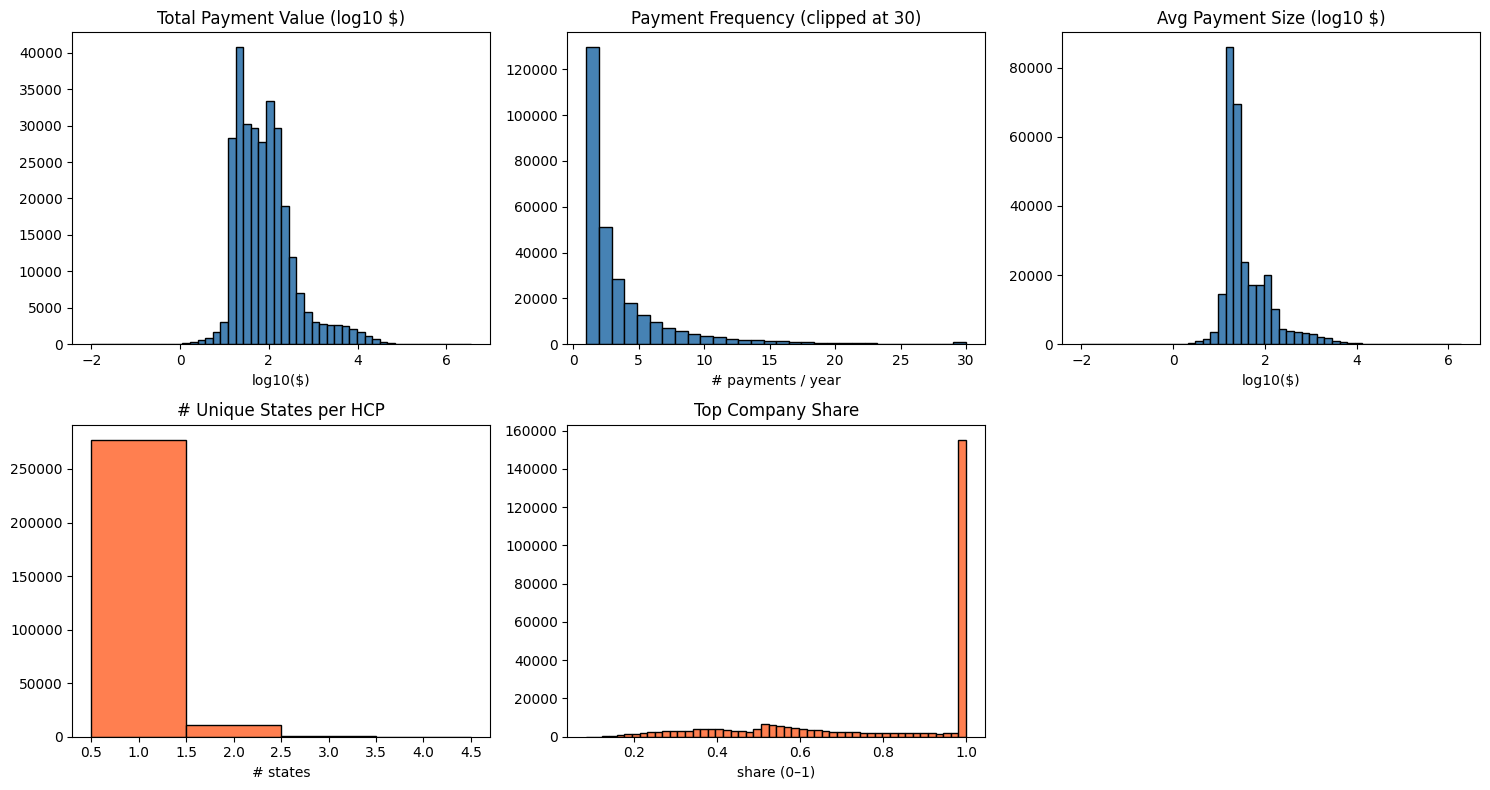

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].hist(np.log10(hcp['total_payment_value'].clip(lower=0.01)), bins=50,
                color='steelblue', edgecolor='black')
axes[0, 0].set_title('Total Payment Value (log10 $)')
axes[0, 0].set_xlabel('log10($)')

axes[0, 1].hist(hcp['payment_frequency'].clip(upper=30), bins=30,
                color='steelblue', edgecolor='black')
axes[0, 1].set_title('Payment Frequency (clipped at 30)')
axes[0, 1].set_xlabel('# payments / year')

axes[0, 2].hist(np.log10(hcp['avg_payment_size'].clip(lower=0.01)), bins=50,
                color='steelblue', edgecolor='black')
axes[0, 2].set_title('Avg Payment Size (log10 $)')
axes[0, 2].set_xlabel('log10($)')

axes[1, 0].hist(hcp['n_unique_states'], bins=range(1, 6),
                color='coral', edgecolor='black', align='left')
axes[1, 0].set_title('# Unique States per HCP')
axes[1, 0].set_xlabel('# states')

axes[1, 1].hist(hcp['top_company_share'], bins=50,
                color='coral', edgecolor='black')
axes[1, 1].set_title('Top Company Share')
axes[1, 1].set_xlabel('share (0–1)')

axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('../output/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Anomaly Detection

Two complementary methods plus one compliance-specific rule:

| Method | What it catches | Why we use it |
|---|---|---|
| **Within-specialty z-score** | "Unusual *for your peer group*" | Different specialties have wildly different baseline payment patterns. Standardizing within specialty isolates relative outliers. |
| **Global IQR (Q3 + 1.5·IQR)** | "Unusual on the absolute scale" | Right-skewed payment distributions inflate the standard deviation, hiding true outliers from z-score. IQR is robust to skew. |
| **Concentration rule** | "Captured by one manufacturer" | A high `top_company_share` combined with meaningful payment volume is the signature of a concentrated economic relationship — the pattern compliance teams care about. |

Combined into a tiered risk classifier: **HIGH** = all three signals fire, **MEDIUM** = any two, **LOW** = any one, **NONE** = zero.

In [9]:
hcp = pd.read_csv("../output/hcp_features.csv")  # skip if already in memory

# === Specialty size annotation ===
MIN_SPECIALTY_SIZE = 30
specialty_sizes = hcp['specialty'].value_counts()
hcp['specialty_size'] = hcp['specialty'].map(specialty_sizes)
hcp['has_specialty_zscore'] = hcp['specialty_size'] >= MIN_SPECIALTY_SIZE

n_qualifying_specialties = (specialty_sizes >= MIN_SPECIALTY_SIZE).sum()
print(f"Qualifying specialties (≥{MIN_SPECIALTY_SIZE} HCPs): "
      f"{n_qualifying_specialties} of {len(specialty_sizes)}")
print(f"HCPs covered: {hcp['has_specialty_zscore'].sum():,} of {len(hcp):,} "
      f"({hcp['has_specialty_zscore'].mean()*100:.1f}%)")

# === Within-specialty z-scores ===
ZSCORE_FEATURES = ['total_payment_value', 'payment_frequency', 'avg_payment_size']

for col in ZSCORE_FEATURES:
    # Compute z-score within each specialty (transform aligns back to original index)
    z = hcp.groupby('specialty')[col].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else np.nan
    )
    # Mask out HCPs in small specialties
    hcp[f'{col}_zscore'] = z.where(hcp['has_specialty_zscore'])
    # Replace inf (rare edge case from constant-value specialties)
    hcp[f'{col}_zscore'] = hcp[f'{col}_zscore'].replace([np.inf, -np.inf], np.nan)

# === Quick summary ===
print(f"\nZ-score distribution stats (HCPs with valid specialty z-scores):")
print(hcp[[f'{c}_zscore' for c in ZSCORE_FEATURES]].describe().round(2))

print(f"\nHCPs flagged at z > 2 (per feature):")
for col in ZSCORE_FEATURES:
    n = (hcp[f'{col}_zscore'] > 2).sum()
    print(f"  {col:25s}  {n:>6,}  ({n/len(hcp)*100:.2f}%)")

Qualifying specialties (≥30 HCPs): 167 of 263
HCPs covered: 287,978 of 288,942 (99.7%)

Z-score distribution stats (HCPs with valid specialty z-scores):
       total_payment_value_zscore  payment_frequency_zscore  avg_payment_size_zscore
count                   287978.00                 287978.00                287978.00
mean                        -0.00                      0.00                     0.00
std                          1.00                      1.00                     1.00
min                         -1.16                     -0.92                    -1.13
25%                         -0.16                     -0.56                    -0.13
50%                         -0.11                     -0.37                    -0.08
75%                         -0.06                      0.21                    -0.03
max                         85.87                     30.48                   111.30

HCPs flagged at z > 2 (per feature):
  total_payment_value         4,339  (1.50%)

In [10]:
# === Global IQR outlier flags ===
IQR_FEATURES = ['total_payment_value', 'payment_frequency', 'avg_payment_size']

print("IQR thresholds and flag counts:\n")
print(f"{'Feature':<25s} {'Q1':>10s} {'Q3':>10s} {'IQR':>10s} {'Upper':>14s} {'Flagged':>10s} {'%':>7s}")
print("-" * 92)

for col in IQR_FEATURES:
    Q1 = hcp[col].quantile(0.25)
    Q3 = hcp[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR

    hcp[f'{col}_iqr_outlier'] = hcp[col] > upper
    n = hcp[f'{col}_iqr_outlier'].sum()
    pct = n / len(hcp) * 100

    print(f"{col:<25s} {Q1:>10.2f} {Q3:>10.2f} {IQR:>10.2f} {upper:>14.2f} {n:>10,} {pct:>6.2f}%")

# === Compare z-score vs IQR catches ===
print(f"\nMethod overlap (z>2 vs IQR upper outlier):\n")
for col in IQR_FEATURES:
    z_flag = (hcp[f'{col}_zscore'] > 2).fillna(False)
    iqr_flag = hcp[f'{col}_iqr_outlier']

    both     = (z_flag & iqr_flag).sum()
    z_only   = (z_flag & ~iqr_flag).sum()
    iqr_only = (~z_flag & iqr_flag).sum()

    print(f"  {col}:")
    print(f"    Both methods agree:  {both:>7,}")
    print(f"    Only z-score (>2):   {z_only:>7,}")
    print(f"    Only IQR:            {iqr_only:>7,}")

IQR thresholds and flag counts:

Feature                           Q1         Q3        IQR          Upper    Flagged       %
--------------------------------------------------------------------------------------------
total_payment_value            25.18     162.65     137.47         368.86     34,558  11.96%
payment_frequency               1.00       4.00       3.00           8.50     26,322   9.11%
avg_payment_size               17.98      62.63      44.65         129.61     36,509  12.64%

Method overlap (z>2 vs IQR upper outlier):

  total_payment_value:
    Both methods agree:    4,335
    Only z-score (>2):         4
    Only IQR:             30,223
  payment_frequency:
    Both methods agree:    9,765
    Only z-score (>2):     2,548
    Only IQR:             16,557
  avg_payment_size:
    Both methods agree:    2,809
    Only z-score (>2):         2
    Only IQR:             33,700


In [11]:
# === Three combined signals ===
hcp['signal_high_value'] = (
    (hcp['total_payment_value_zscore'] > 2).fillna(False)
    | hcp['total_payment_value_iqr_outlier']
)
hcp['signal_high_frequency'] = (
    (hcp['payment_frequency_zscore'] > 2).fillna(False)
    | hcp['payment_frequency_iqr_outlier']
)
hcp['signal_concentrated'] = hcp['top_company_share'] > 0.7

# === Count signals + assign tier ===
hcp['n_signals'] = (
    hcp['signal_high_value'].astype(int)
    + hcp['signal_high_frequency'].astype(int)
    + hcp['signal_concentrated'].astype(int)
)

conditions = [hcp['n_signals'] == 3, hcp['n_signals'] == 2, hcp['n_signals'] == 1]
choices    = ['HIGH', 'MEDIUM', 'LOW']
hcp['risk_tier'] = np.select(conditions, choices, default='NONE')

# === Tier summary ===
print("Risk tier breakdown:\n")
tier_counts = hcp['risk_tier'].value_counts().reindex(['HIGH', 'MEDIUM', 'LOW', 'NONE'])
for tier, count in tier_counts.items():
    pct = count / len(hcp) * 100
    print(f"  {tier:<8s} {count:>8,}  ({pct:>5.2f}%)")

flagged_total = (hcp['risk_tier'] != 'NONE').sum()
print(f"\nAny-tier flagged: {flagged_total:,} ({flagged_total/len(hcp)*100:.1f}%)")

# === Signal composition by tier (which signals fired in each tier) ===
print("\nSignal composition by tier:")
for tier in ['HIGH', 'MEDIUM', 'LOW']:
    subset = hcp[hcp['risk_tier'] == tier]
    if len(subset) == 0:
        continue
    print(f"  {tier} ({len(subset):,} HCPs):")
    print(f"    high_value:     {subset['signal_high_value'].mean()*100:>5.1f}%")
    print(f"    high_frequency: {subset['signal_high_frequency'].mean()*100:>5.1f}%")
    print(f"    concentrated:   {subset['signal_concentrated'].mean()*100:>5.1f}%")

# === Top 10 HIGH-risk HCPs (by total payment value) ===
print("\nTop 10 HIGH-risk HCPs by total payment value:\n")
display_cols = [
    'specialty', 'primary_state', 'total_payment_value',
    'payment_frequency', 'top_company_share', 'top_company_name'
]
top_10 = (
    hcp[hcp['risk_tier'] == 'HIGH']
    .nlargest(10, 'total_payment_value')
    [display_cols]
)
print(top_10.to_string(index=False))

# === Save enriched table ===
hcp.to_csv("../output/hcp_features_with_flags.csv", index=False)
print(f"\nSaved to ../output/hcp_features_with_flags.csv")
print(f"Shape: {hcp.shape}")

Risk tier breakdown:

  HIGH        4,979  ( 1.72%)
  MEDIUM     26,583  ( 9.20%)
  LOW       181,351  (62.76%)
  NONE       76,029  (26.31%)

Any-tier flagged: 212,913 (73.7%)

Signal composition by tier:
  HIGH (4,979 HCPs):
    high_value:     100.0%
    high_frequency: 100.0%
    concentrated:   100.0%
  MEDIUM (26,583 HCPs):
    high_value:      97.7%
    high_frequency:  30.3%
    concentrated:    72.0%
  LOW (181,351 HCPs):
    high_value:       2.0%
    high_frequency:   8.7%
    concentrated:    89.3%

Top 10 HIGH-risk HCPs by total payment value:

                                                                                       specialty primary_state  total_payment_value  payment_frequency  top_company_share              top_company_name
Allopathic & Osteopathic Physicians|Orthopaedic Surgery|Adult Reconstructive Orthopaedic Surgery            ID           3200055.07                 14           0.999809  Zimmer Biomet Holdings, Inc.
               Allopathic & Osteopat

In [13]:
# === Refine the concentration signal: must clear a value floor ===
VALUE_FLOOR = 500  # $500/year — strips out the single-lunch HCPs

hcp['signal_concentrated'] = (
    (hcp['top_company_share'] > 0.7)
    & (hcp['total_payment_value'] > VALUE_FLOOR)
)

# === Recompute n_signals + tier ===
hcp['n_signals'] = (
    hcp['signal_high_value'].astype(int)
    + hcp['signal_high_frequency'].astype(int)
    + hcp['signal_concentrated'].astype(int)
)

conditions = [hcp['n_signals'] == 3, hcp['n_signals'] == 2, hcp['n_signals'] == 1]
choices    = ['HIGH', 'MEDIUM', 'LOW']
hcp['risk_tier'] = np.select(conditions, choices, default='NONE')

# === New tier breakdown ===
print("Refined risk tier breakdown (concentration requires value > $500):\n")
tier_counts = hcp['risk_tier'].value_counts().reindex(['HIGH', 'MEDIUM', 'LOW', 'NONE'])
for tier, count in tier_counts.items():
    pct = count / len(hcp) * 100
    print(f"  {tier:<8s} {count:>8,}  ({pct:>5.2f}%)")

flagged = (hcp['risk_tier'] != 'NONE').sum()
print(f"\nAny-tier flagged: {flagged:,} ({flagged/len(hcp)*100:.1f}%)")

# === Signal composition (sanity check) ===
print("\nSignal composition by tier:")
for tier in ['HIGH', 'MEDIUM', 'LOW']:
    subset = hcp[hcp['risk_tier'] == tier]
    if len(subset) == 0:
        continue
    print(f"  {tier} ({len(subset):,} HCPs):")
    print(f"    high_value:     {subset['signal_high_value'].mean()*100:>5.1f}%")
    print(f"    high_frequency: {subset['signal_high_frequency'].mean()*100:>5.1f}%")
    print(f"    concentrated:   {subset['signal_concentrated'].mean()*100:>5.1f}%")

# === Save final enriched table ===
hcp.to_csv("../output/hcp_features_with_flags.csv", index=False)
print(f"\nSaved final enriched table. Shape: {hcp.shape}")

Refined risk tier breakdown (concentration requires value > $500):

  HIGH        4,819  ( 1.67%)
  MEDIUM     23,423  ( 8.11%)
  LOW        22,772  ( 7.88%)
  NONE      237,928  (82.34%)

Any-tier flagged: 51,014 (17.7%)

Signal composition by tier:
  HIGH (4,819 HCPs):
    high_value:     100.0%
    high_frequency: 100.0%
    concentrated:   100.0%
  MEDIUM (23,423 HCPs):
    high_value:     100.0%
    high_frequency:  32.4%
    concentrated:    67.6%
  LOW (22,772 HCPs):
    high_value:      27.8%
    high_frequency:  72.2%
    concentrated:     0.0%

Saved final enriched table. Shape: (288942, 25)


## Output Summary

Three files saved to `output/`:

| File | Rows | Purpose |
|---|---|---|
| `payments_sampled.csv` | ~989K | 10% transactional sample, used for Tableau drill-down and trend |
| `hcp_features.csv` | ~289K | HCP-level features (no flags) |
| `hcp_features_with_flags.csv` | ~289K | HCP-level features + risk tier (the canonical Tableau input) |

**Key finding:** Orthopedic surgery is the highest-risk specialty. The top 10 HIGH-risk HCPs are all orthopedic surgeons or related sub-specialists, with 9 of 10 receiving >99% of their payments from a single device manufacturer (Stryker, Arthrex, Zimmer Biomet, or Boston Scientific).

See the live Tableau Public dashboard for interactive exploration.